Dataset loaded successfully!
Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length 

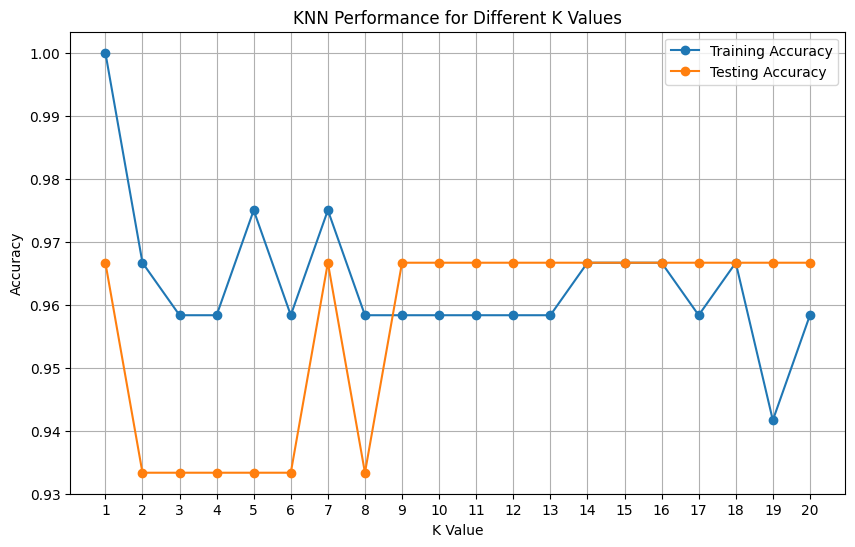


Final KNN Model
----------------------------
Selected K: 1
Final Test Accuracy: 0.9666666666666667

Final Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Final Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


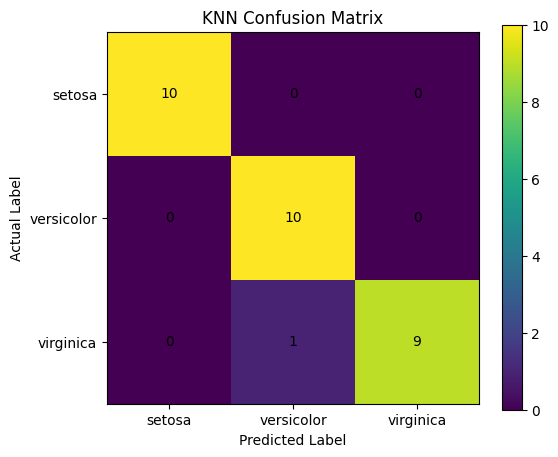


TASK 30 - KNN COMPLETED SUCCESSFULLY
Dataset: Iris
Algorithm: K-Nearest Neighbors
Feature Scaling: StandardScaler
K Values Tested: 1 to 20
Best K: 1
Best Test Accuracy: 0.9666666666666667


In [5]:
# ============================================================
# TASK 30 - K-NEAREST NEIGHBORS (KNN)
# Data Science Track - Level 2 Day 30
# ============================================================

# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 2. Load Iris Dataset
# ------------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Dataset shape:", X.shape)
print("Features:", iris.feature_names)
print("Target classes:", iris.target_names)


# ------------------------------------------------------------
# 3. Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

print("\nFirst 5 rows:")
print(df.head())


# ------------------------------------------------------------
# 4. Basic Data Checking
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Description:")
print(df.describe())


# ------------------------------------------------------------
# 5. Separate Features and Target
# ------------------------------------------------------------

X = df.drop("target", axis=1)
y = df["target"]


# ------------------------------------------------------------
# 6. Split Data into Training and Testing Sets
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


# ------------------------------------------------------------
# 7. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ------------------------------------------------------------
# 8. Create KNN Model with K = 5
# ------------------------------------------------------------

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)


# ------------------------------------------------------------
# 9. Make Predictions
# ------------------------------------------------------------

y_pred = knn.predict(X_test_scaled)

print("\nPredictions:")
print(y_pred)


# ------------------------------------------------------------
# 10. Evaluate K = 5 Model
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy with K = 5:")
print(accuracy)


# ------------------------------------------------------------
# 11. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


# ------------------------------------------------------------
# 12. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# 13. Test Different K Values
# ------------------------------------------------------------

k_values = range(1, 21)

train_accuracy = []
test_accuracy = []

for k in k_values:

    knn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    knn_model.fit(
        X_train_scaled,
        y_train
    )

    train_prediction = knn_model.predict(
        X_train_scaled
    )

    test_prediction = knn_model.predict(
        X_test_scaled
    )

    train_acc = accuracy_score(
        y_train,
        train_prediction
    )

    test_acc = accuracy_score(
        y_test,
        test_prediction
    )

    train_accuracy.append(train_acc)
    test_accuracy.append(test_acc)


# ------------------------------------------------------------
# 14. Create Performance Comparison Table
# ------------------------------------------------------------

results = pd.DataFrame({
    "K": list(k_values),
    "Training Accuracy": train_accuracy,
    "Testing Accuracy": test_accuracy
})

print("\nKNN Performance Comparison:")
print(results.to_string(index=False))


# ------------------------------------------------------------
# 15. Find Best K
# ------------------------------------------------------------

best_index = np.argmax(test_accuracy)

best_k = list(k_values)[best_index]
best_test_accuracy = test_accuracy[best_index]

print("\n-----------------------------------")
print("Best K:", best_k)
print("Best Test Accuracy:", best_test_accuracy)
print("-----------------------------------")


# ------------------------------------------------------------
# 16. Plot K vs Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    k_values,
    test_accuracy,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Performance for Different K Values")

plt.xticks(list(k_values))

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 17. Train Final KNN Model Using Best K
# ------------------------------------------------------------

final_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

final_knn.fit(
    X_train_scaled,
    y_train
)


# ------------------------------------------------------------
# 18. Final Predictions
# ------------------------------------------------------------

final_predictions = final_knn.predict(
    X_test_scaled
)


# ------------------------------------------------------------
# 19. Final Model Accuracy
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("\nFinal KNN Model")
print("----------------------------")
print("Selected K:", best_k)
print("Final Test Accuracy:", final_accuracy)


# ------------------------------------------------------------
# 20. Final Classification Report
# ------------------------------------------------------------

print("\nFinal Classification Report:")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=iris.target_names
    )
)


# ------------------------------------------------------------
# 21. Final Confusion Matrix
# ------------------------------------------------------------

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("\nFinal Confusion Matrix:")
print(final_cm)


# ------------------------------------------------------------
# 22. Visualize Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1, 2],
    iris.target_names
)

plt.yticks(
    [0, 1, 2],
    iris.target_names
)

plt.colorbar()

# Display values inside the matrix
for i in range(final_cm.shape[0]):
    for j in range(final_cm.shape[1]):
        plt.text(
            j,
            i,
            final_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()


# ------------------------------------------------------------
# 23. Final Summary
# ------------------------------------------------------------

print("\n========================================")
print("TASK 30 - KNN COMPLETED SUCCESSFULLY")
print("========================================")

print("Dataset: Iris")
print("Algorithm: K-Nearest Neighbors")
print("Feature Scaling: StandardScaler")
print("K Values Tested: 1 to 20")
print("Best K:", best_k)
print("Best Test Accuracy:", best_test_accuracy)
print("========================================")